In [1]:
import numpy as np
from joblib import load
from loguru import logger
from torch import Tensor
from transformers import BartForConditionalGeneration, BertForSequenceClassification
import plotly.io as pio
pio.renderers.default = "svg" # uncomment this if want interactive renderer
from carl.environment.sokoban.tokenizer import SokobanTokenizer
from carl.environment.sokoban.env import SokobanEnv

from carl.inference_components.conditional_low_level_policy import (
    ConditionalLowLevelPolicy,
    TransformerConditionalLowLevelPolicy,
)
from carl.inference_components.policy import Policy, TransformerPolicy
from carl.inference_components.subgoal_generator import (
    SubgoalGenerator,
    TransformerSubgoalGenerator,
)
from carl.inference_components.value import TransformerValue, Value

logger.info('testing inference components')

2025-01-26 21:37:17.313 | INFO     | __main__:<module>:29 - testing inference components


# Env and dataset

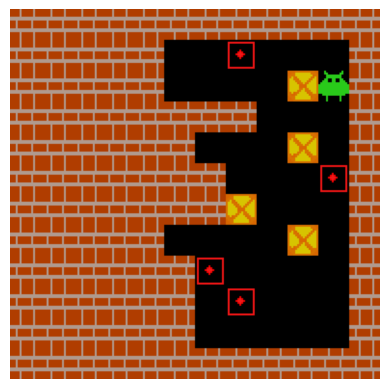

In [2]:
import joblib as jl
datapath = './rl-data/validation/sokoban/progress/boards_1000_b4_gs100_c300_p0.35/boards_1000_b4_gs100_c300_p0.35.joblib'
data = jl.load(datapath)

env = SokobanEnv(SokobanTokenizer(None, size_of_board=(12, 12)), num_boxes=4)
env.state_to_repr(data[0])

2025-01-26 21:37:17.411 | INFO     | __main__:<module>:1 - setting up the environment
2025-01-26 21:37:17.413 | INFO     | __main__:<module>:2 - It is important to set the categorical distance to 100, because the model was trained with this value. Also the size of the board should be (12, 12), because the model was trained with this value.


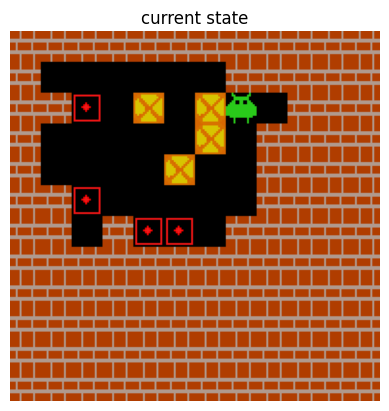

2025-01-26 21:37:18.028 | INFO     | __main__:<module>:14 - state after k is the state after k steps, where k is the number of steps the agent should take. In this case k = 3.


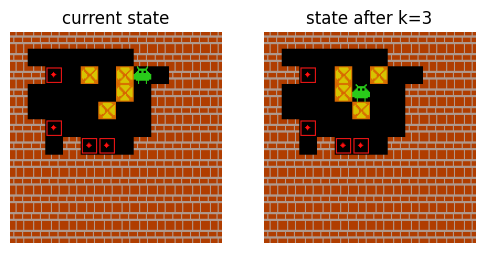

In [3]:
logger.info('setting up the environment')
logger.info(
    'It is important to set the categorical distance to 100, because the model was trained with this value. Also the '
    'size of the board should be (12, 12), because the model was trained with this value.'
)
env = SokobanEnv(SokobanTokenizer(cut_distance=None, size_of_board=(12, 12)), num_boxes=4)

# logger.info('setting up the dataset')
path_to_dataset: str = './rl-data/validation/sokoban/offline/12-12-4/sokoban_12_12_4_trajectories_part_88.pkl'
dataset: dict[int, list[np.ndarray]] = load(path_to_dataset)
keys = list(dataset.keys())
current_state: np.ndarray = dataset[keys[1]][1]
display(env.state_to_repr(current_state, title='current state'))
logger.info(
    'state after k is the state after k steps, where k is the number of steps the agent should take. In this '
    'case k = 3.'
)
state_after_k: np.ndarray = dataset[keys[1]][4]
display(env.many_states_to_repr([current_state, state_after_k], titles=['current state', 'state after k=3']))

In [4]:
from carl.environment.instance_generator import (
    GeneralIterableDataLoader,
    BasicInstanceGenerator,
)

# rl-data/validation/sokoban/offline/12-12-4
path_to_folder_with_data = './rl-data/validation/sokoban/progress/boards_1000_b4_gs25_c300_p0.35'   # path to the folder with trajectories
# its a dict mapping id of trajectory to the list of states in this trajectory
env = SokobanEnv(SokobanTokenizer(None, size_of_board=(12, 12)), num_boxes=4)
instance_generator = BasicInstanceGenerator(
    generator=GeneralIterableDataLoader(path_to_folder_with_data), batch_size=32
)


initial_state_loader = iter(instance_generator.reset_dataloader())
initial_state = next(initial_state_loader).cpu().numpy()
initial_state.shape, type(initial_state), initial_state.dtype

2025-01-26 21:37:18.178 | DEBUG    | carl.environment.instance_generator:__init__:36 - path: ./rl-data/validation/sokoban/progress/boards_1000_b4_gs100_c300_p0.35
2025-01-26 21:37:18.181 | DEBUG    | carl.environment.instance_generator:get_stream:55 - Found 1 files in ./rl-data/validation/sokoban/progress/boards_1000_b4_gs100_c300_p0.35
2025-01-26 21:37:18.182 | INFO     | carl.environment.instance_generator:process_data:45 - Processing data from ./rl-data/validation/sokoban/progress/boards_1000_b4_gs100_c300_p0.35/boards_1000_b4_gs100_c300_p0.35.joblib


((32, 12, 12, 7), numpy.ndarray, dtype('uint8'))

(12, 12, 7)


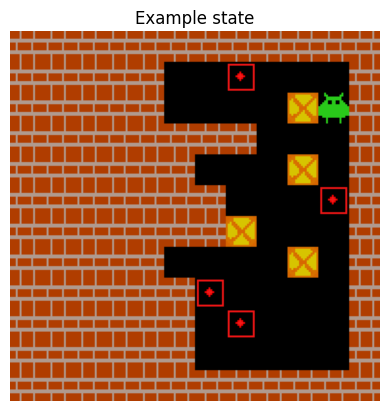

In [5]:
state = env.set_state(initial_state[0, :])
print(state.shape)
env.state_to_repr(state, 'Example state')

2025-01-26 21:37:18.292 | DEBUG    | carl.environment.instance_generator:get_stream:55 - Found 1 files in ./rl-data/validation/sokoban/progress/boards_1000_b4_gs100_c300_p0.35
2025-01-26 21:37:18.294 | INFO     | carl.environment.instance_generator:process_data:45 - Processing data from ./rl-data/validation/sokoban/progress/boards_1000_b4_gs100_c300_p0.35/boards_1000_b4_gs100_c300_p0.35.joblib


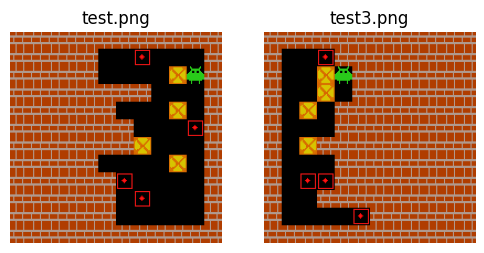

In [6]:
dataloader = iter(instance_generator.reset_dataloader())
state = next(dataloader).cpu().numpy()[0]
state3 = next(dataloader).cpu().numpy()[0]
env.many_states_to_repr([state, state3], ['test.png', 'test3.png'])

In [7]:
components_prefix = './rl-data/validation/sokoban/components/full_data/'
from os.path import join

path_to_policy_weights: str = join(components_prefix, 'policy/checkpoint-94820')
path_to_cllp_weights: str = join(components_prefix, 'cllp/8/checkpoint-167585')
path_to_value_function_weights: str = join(components_prefix, 'value/checkpoint-1343100')
path_to_generator_weights: str = join(components_prefix, 'generator/border/8/checkpoint-75856')

# Policy
### CurrentState $\rightarrow$ Action

In [8]:
current_state.shape

(12, 12, 7)

In [9]:
logger.info('setting up the policy')

policy: Policy = TransformerPolicy(
    policy_network_class=BertForSequenceClassification.from_pretrained,
    path_to_policy_weights=path_to_policy_weights,
    env=env,
    n_actions=2,
)
policy.construct_network()
policy_prediction: Tensor = policy.get_actions(current_state)

logger.info(f'policy prediction - distribution over action: {policy_prediction}')
logger.info(f'Proposed {len(policy_prediction)} actions')
logger.info(f'policy prediction - best action ({policy_prediction[0][0]}) with value {policy_prediction[0][1]}')

2025-01-26 21:37:18.448 | INFO     | __main__:<module>:1 - setting up the policy
2025-01-26 21:37:20.018 | DEBUG    | carl.inference_components.component:instantiate_network:52 - Loading weights from ./rl-data/validation/sokoban/components/full_data/policy/checkpoint-94820
2025-01-26 21:37:20.019 | INFO     | carl.inference_components.component:instantiate_network:73 - Provided direct path to the ckpt
2025-01-26 21:37:20.047 | SUCCESS  | carl.inference_components.component:instantiate_network:85 - Loaded weights from ./rl-data/validation/sokoban/components/full_data/policy/checkpoint-94820
2025-01-26 21:37:20.094 | INFO     | __main__:<module>:12 - policy prediction - distribution over action: [(2, 0.8306242), (1, 0.16886686)]
2025-01-26 21:37:20.095 | INFO     | __main__:<module>:13 - Proposed 2 actions
2025-01-26 21:37:20.096 | INFO     | __main__:<module>:14 - policy prediction - best action (2) with value 0.8306242227554321


True
Using device: cpu


2025-01-26 21:37:20.138 | INFO     | __main__:<module>:12 - Action: 3
2025-01-26 21:37:20.171 | INFO     | __main__:<module>:12 - Action: 0
2025-01-26 21:37:20.198 | INFO     | __main__:<module>:12 - Action: 0
2025-01-26 21:37:20.228 | INFO     | __main__:<module>:12 - Action: 0
2025-01-26 21:37:20.258 | INFO     | __main__:<module>:12 - Action: 1


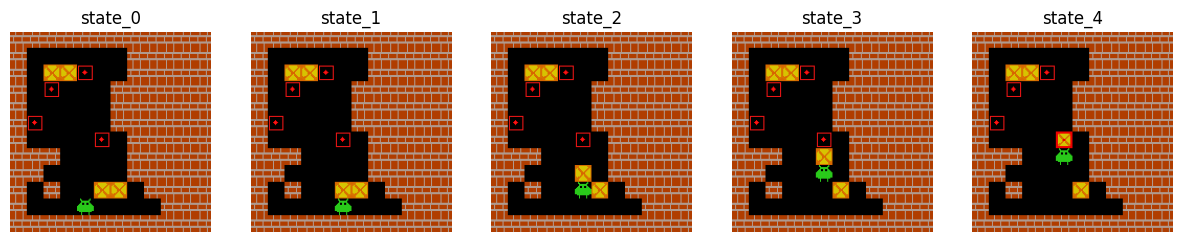

In [10]:
# Lets visualize the policy we have learned

input_state = next(dataloader).cpu().numpy()[0]


visited_states = []
current_state = input_state
for i in range(5):
    visited_states.append(current_state.copy())
    action = policy.get_actions(current_state)
    action = action[0][0]
    logger.info(f'Action: {action}')
    env.set_state(current_state)
    state, _, done, _ = env.step(action)

    current_state = state

    if done:
        break

    if done:
        break

env.many_states_to_repr(
    visited_states, titles=[f'state_{i}' for i in range(len(visited_states) + 1)]
)

# Conditional Low Level Policy
### CurrentState $\times$ SubgoalState $\rightarrow$ Action

In [11]:
cllp: ConditionalLowLevelPolicy = TransformerConditionalLowLevelPolicy(
    BertForSequenceClassification.from_pretrained, path_to_cllp_weights, env
)
cllp.construct_network()

2025-01-26 21:37:20.471 | DEBUG    | carl.inference_components.component:instantiate_network:52 - Loading weights from ./rl-data/validation/sokoban/components/full_data/cllp/8/checkpoint-167585
2025-01-26 21:37:20.473 | INFO     | carl.inference_components.component:instantiate_network:73 - Provided direct path to the ckpt
2025-01-26 21:37:20.509 | SUCCESS  | carl.inference_components.component:instantiate_network:85 - Loaded weights from ./rl-data/validation/sokoban/components/full_data/cllp/8/checkpoint-167585


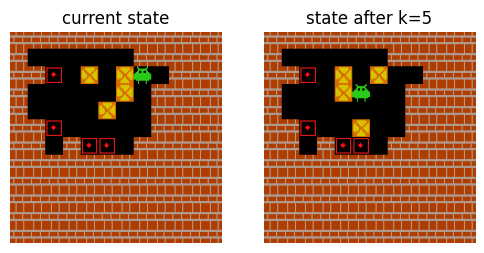

2025-01-26 21:37:20.744 | INFO     | __main__:<module>:15 - Action: 1
2025-01-26 21:37:20.803 | INFO     | __main__:<module>:15 - Action: 2
2025-01-26 21:37:20.856 | INFO     | __main__:<module>:15 - Action: 2
2025-01-26 21:37:20.915 | INFO     | __main__:<module>:15 - Action: 1
2025-01-26 21:37:20.973 | INFO     | __main__:<module>:15 - Action: 0
2025-01-26 21:37:20.976 | SUCCESS  | __main__:<module>:11 - Reached the goal state


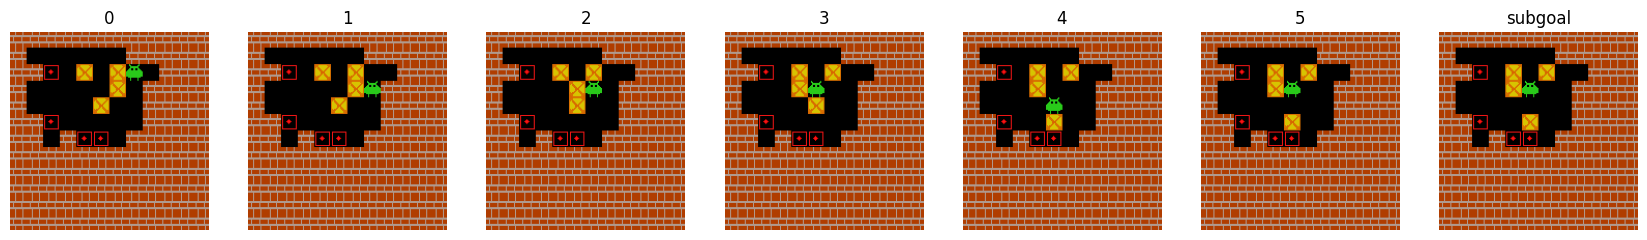

In [12]:
current_state: np.ndarray = dataset[keys[1]][1]
state_after_k: np.ndarray = dataset[keys[1]][6]

display(env.many_states_to_repr([current_state, state_after_k], ['current state', 'state after k=5']))

visited_states = []
env.core.restore_full_state_from_np_array_version(current_state)
for i in range(7):
    visited_states.append(current_state.copy())
    if np.array_equal(current_state, state_after_k):
        logger.success('Reached the goal state')
        break
    action = cllp.get_action(current_state, state_after_k)
    action = action.argmax()
    logger.info(f'Action: {action}')
    env.set_state(current_state)
    state, _, done, _ = env.step(action)

    current_state = state


env.many_states_to_repr(
    [*visited_states, state_after_k], [*list(range(len(visited_states))), 'subgoal']
)

# Value function

2025-01-26 21:37:21.575 | DEBUG    | carl.inference_components.component:instantiate_network:52 - Loading weights from ./rl-data/validation/sokoban/components/full_data/value/checkpoint-1343100
2025-01-26 21:37:21.577 | INFO     | carl.inference_components.component:instantiate_network:73 - Provided direct path to the ckpt
2025-01-26 21:37:21.592 | SUCCESS  | carl.inference_components.component:instantiate_network:85 - Loaded weights from ./rl-data/validation/sokoban/components/full_data/value/checkpoint-1343100


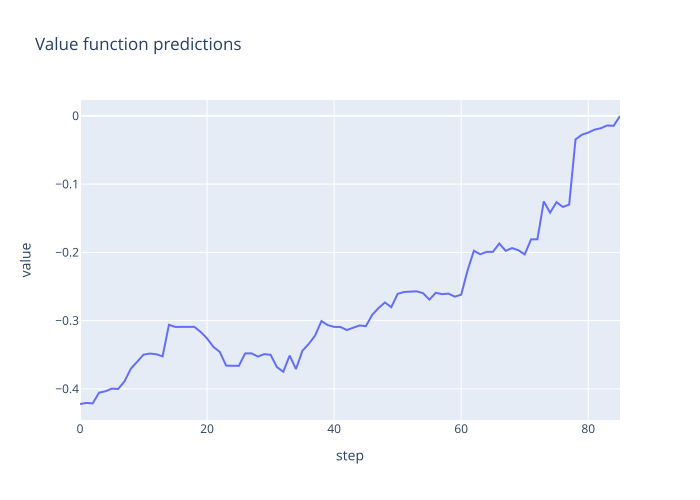

In [13]:
import plotly.graph_objects as go

value_function: Value = TransformerValue(
    value_network_class=BertForSequenceClassification.from_pretrained,
    path_to_value_network_weights=path_to_value_function_weights,
    env=env,
    type_of_evaluation='regression',
)

value_function.construct_network()
# value_function_prediction: float = value_function.get_value(current_state)
# solved_state = dataset[keys[1]][-1]
# logger.info(f'value function prediction of unsolved state: {value_function_prediction}')
# logger.info(f'value function prediction of solved state: {value_function.get_value(solved_state)}')
states = [state for state in dataset[keys[11]]]
values = [value_function.get_value(state) for state in states] # can be batched too


fig = go.Figure()
fig.add_trace(go.Scatter(x=list(range(len(values))), y=values))
fig.update_layout(title='Value function predictions', xaxis_title='step', yaxis_title='value')
fig.show()

# Goal Generator

2025-01-26 21:37:23.540 | INFO     | __main__:<module>:3 - setting up the subgoal generator
2025-01-26 21:37:23.541 | DEBUG    | carl.inference_components.component:instantiate_network:52 - Loading weights from ./rl-data/validation/sokoban/components/full_data/generator/border/8/checkpoint-75856
2025-01-26 21:37:23.543 | INFO     | carl.inference_components.component:instantiate_network:73 - Provided direct path to the ckpt
2025-01-26 21:37:23.618 | SUCCESS  | carl.inference_components.component:instantiate_network:85 - Loaded weights from ./rl-data/validation/sokoban/components/full_data/generator/border/8/checkpoint-75856


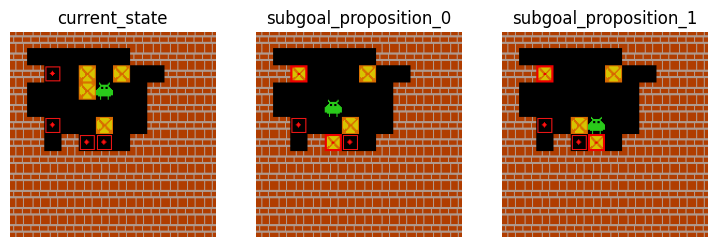

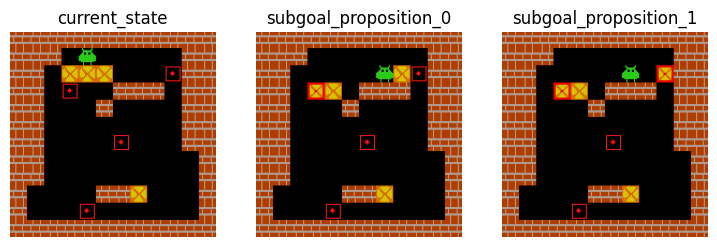

In [14]:
from carl.solver.nodes import SearchTreeNode

logger.info('setting up the subgoal generator')
subgoal_generation_kwargs: dict[str, int] = {
    'num_beams': 8,
    'num_return_sequences': 2,
    'max_new_tokens': 145,
}
generator: SubgoalGenerator = TransformerSubgoalGenerator(
    BartForConditionalGeneration.from_pretrained,
    path_to_generator_weights,
    env,
    subgoal_generation_kwargs,
)
generator.construct_network()

current_state2 = next(dataloader).cpu().numpy()[0]

nodes = [
    SearchTreeNode(
        state=current_state,
        value=0.0,
        low_level_path=[],
        parent_node=None,
        next_expand_with_k_generator=8,
    ),
    SearchTreeNode(
        state=current_state2,
        value=0.0,
        low_level_path=[],
        parent_node=None,
        next_expand_with_k_generator=8,
    ),
]

subgoals_0 = generator.get_subgoals(nodes[0])
subgoals_1 = generator.get_subgoals(nodes[1])

for input_node, subgoals in zip(nodes, [subgoals_0, subgoals_1]):
    fig = env.many_states_to_repr(
        [input_node.state, *[subgoal.state for subgoal in subgoals]],
        ['current_state', *[f'subgoal_proposition_{i}' for i in range(len(subgoals))]],
    )

    display(fig)



In [15]:
generator.get_network()

BartForConditionalGeneration(
  (model): BartModel(
    (shared): BartScaledWordEmbedding(22, 512, padding_idx=1)
    (encoder): BartEncoder(
      (embed_tokens): BartScaledWordEmbedding(22, 512, padding_idx=1)
      (embed_positions): BartLearnedPositionalEmbedding(514, 512)
      (layers): ModuleList(
        (0-5): 6 x BartEncoderLayer(
          (self_attn): BartSdpaAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=512, out_features=2048, bias=True)
          (fc2): Linear(in_features=2048, out_features=512, bias=True)
          (final_layer_norm

# CLLP with Goal Generator - evaluation

In [16]:
from importlib import reload
import carl.inference_components.cllp_utils as cllp_utils

reload(cllp_utils)

<module 'carl.inference_components.cllp_utils' from '/home/mtyrolski/dev/carl/CaRL/carl/inference_components/cllp_utils.py'>

## With generator-generated goals

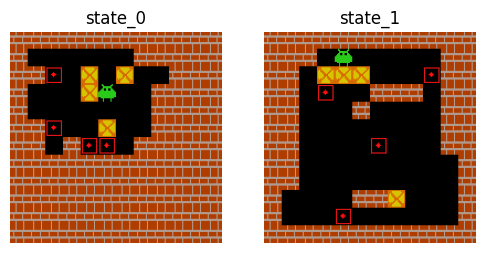

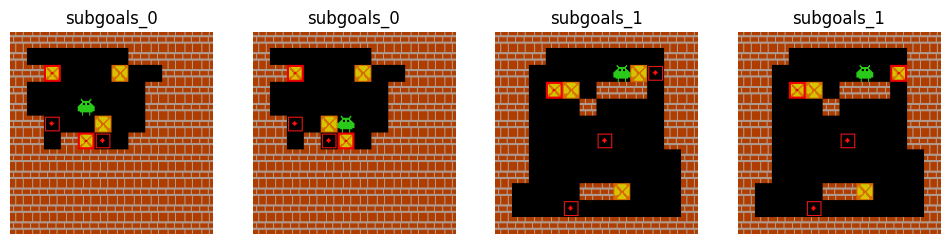

In [17]:
display(env.many_states_to_repr([node.state for node in nodes], ['state_0', 'state_1']))
subgoals_first = [subgoal.state for subgoal in subgoals_0]
subgoals_second = [subgoal.state for subgoal in subgoals_1]
env.many_states_to_repr([*subgoals_first, *subgoals_second], ['subgoals_0' for _ in range(len(subgoals_first))] + ['subgoals_1' for _ in range(len(subgoals_second))])

In [18]:
results = []
for input_node, subgoal_predictions in zip(nodes, [subgoals_0, subgoals_1]):
    cllp_ver_result = cllp_utils.verify_cllp_reaches_subgoals_from_initial_state(
        cllp=cllp,
        goals=[subgoal.state for subgoal in subgoal_predictions],
        initial_state=input_node.state,
        env_creation_fn=lambda: env,
        max_radius=10,
        add_first_batch_to_node_computations=True,
    )
    results.append(cllp_ver_result)
results

[CLLPVerificationResult(success_rate=1.0, total_goals=2, reached=array([ True,  True]), calls=2, cllp_samples_in_calls=16, node_computations=16, paths=[[0, 2, 2, 3, 1, 1, 1, 0], [0, 2, 2, 3, 1, 1, 3, 1]]),
 CLLPVerificationResult(success_rate=1.0, total_goals=2, reached=array([ True,  True]), calls=2, cllp_samples_in_calls=18, node_computations=18, paths=[[2, 1, 0, 3, 1, 3, 3, 3], [2, 1, 0, 3, 1, 3, 3, 3, 3, 2]])]

2025-01-26 21:37:31.122 | INFO     | __main__:<module>:7 - Verification result for node: CLLPVerificationResult(success_rate=1.0, total_goals=2, reached=array([ True,  True]), calls=2, cllp_samples_in_calls=16, node_computations=16, paths=[[0, 2, 2, 3, 1, 1, 1, 0], [0, 2, 2, 3, 1, 1, 3, 1]])


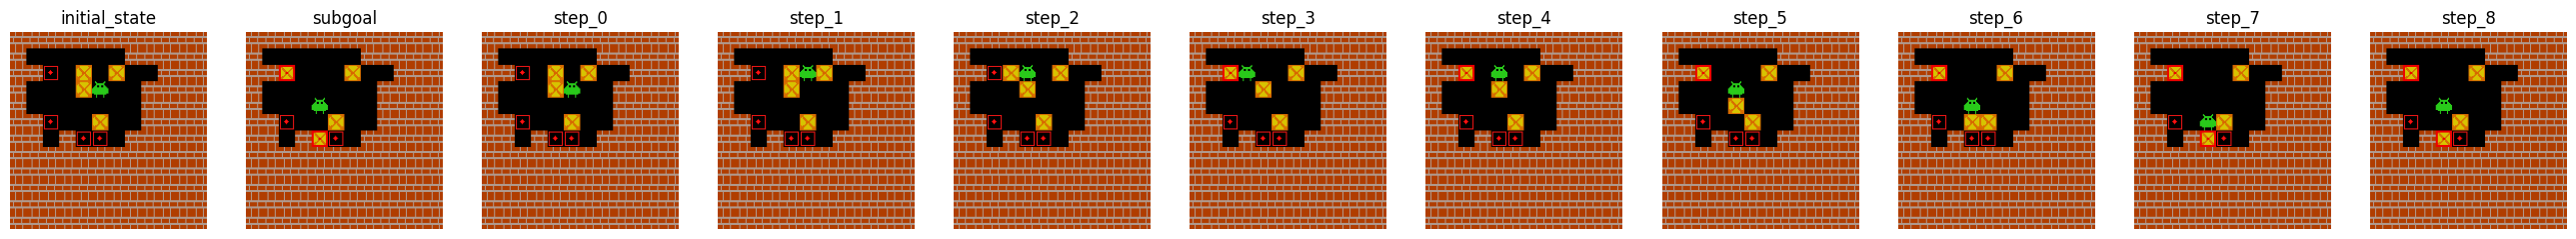

Additional validation using validator


2025-01-26 21:37:31.995 | INFO     | __main__:<module>:16 - Validator result: True (path: [0, 2, 2, 3, 1, 1, 1, 0])


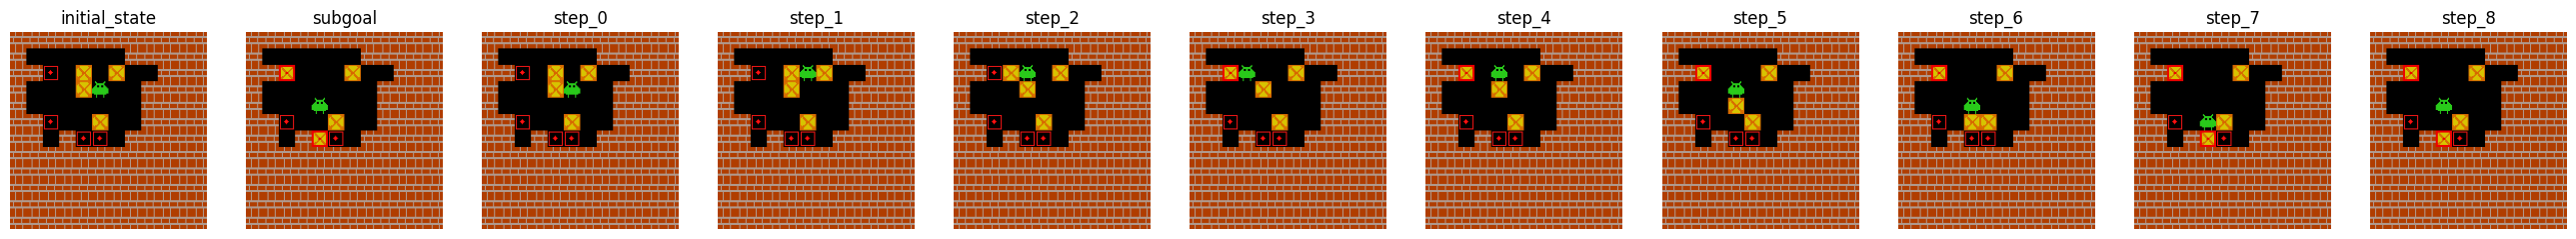

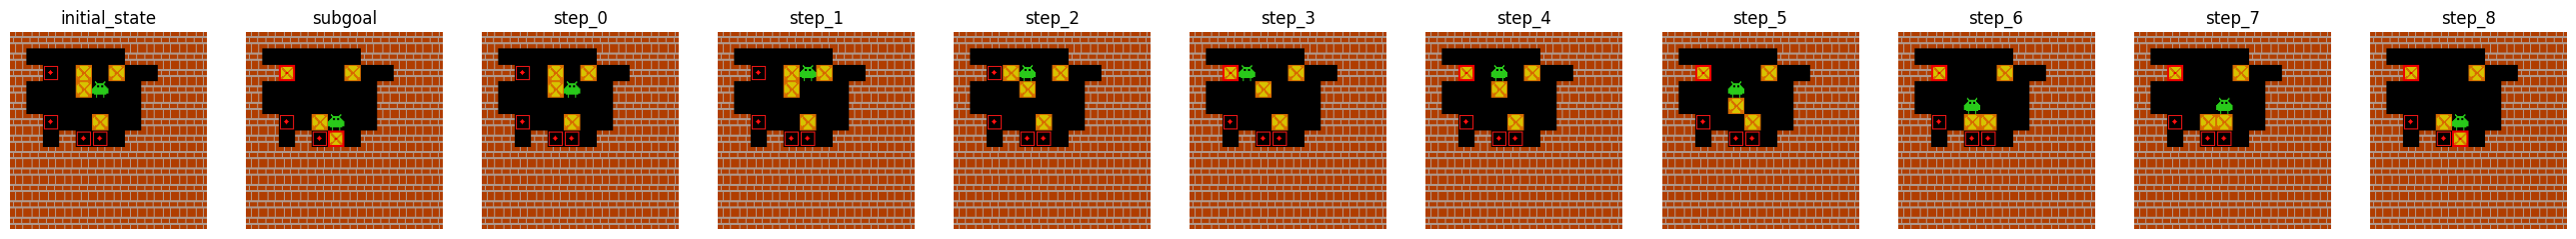

Additional validation using validator


2025-01-26 21:37:33.476 | INFO     | __main__:<module>:16 - Validator result: True (path: [0, 2, 2, 3, 1, 1, 3, 1])


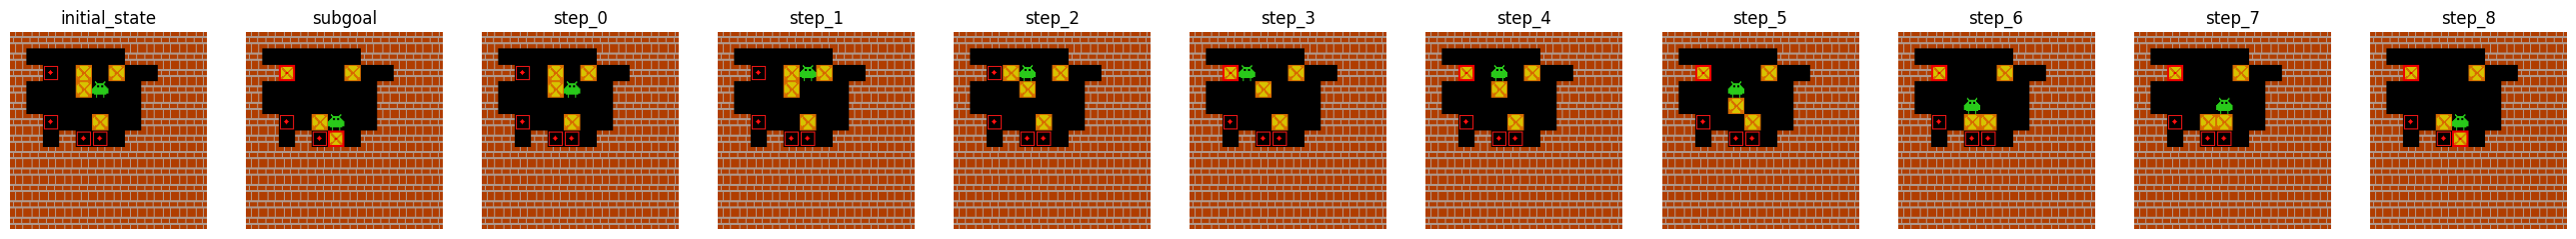

2025-01-26 21:37:33.969 | INFO     | __main__:<module>:7 - Verification result for node: CLLPVerificationResult(success_rate=1.0, total_goals=2, reached=array([ True,  True]), calls=2, cllp_samples_in_calls=18, node_computations=18, paths=[[2, 1, 0, 3, 1, 3, 3, 3], [2, 1, 0, 3, 1, 3, 3, 3, 3, 2]])


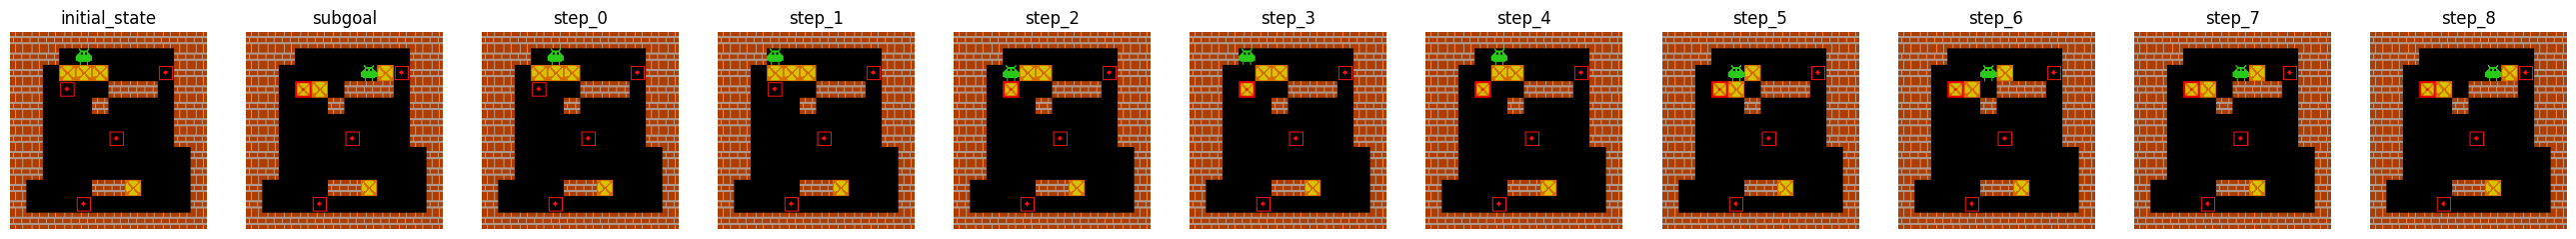

Additional validation using validator


2025-01-26 21:37:34.947 | INFO     | __main__:<module>:16 - Validator result: True (path: [2, 1, 0, 3, 1, 3, 3, 3])


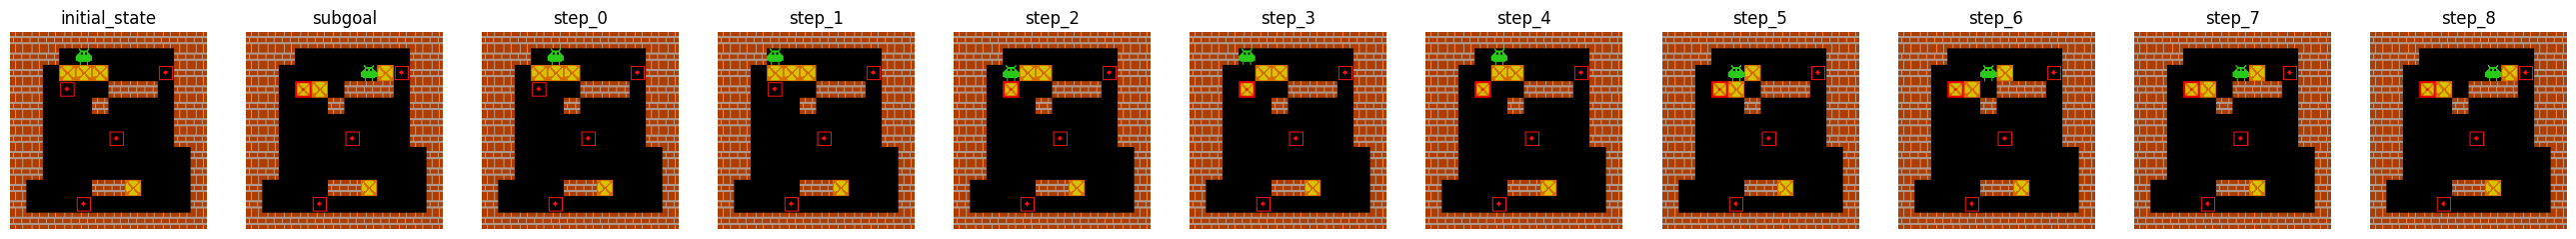

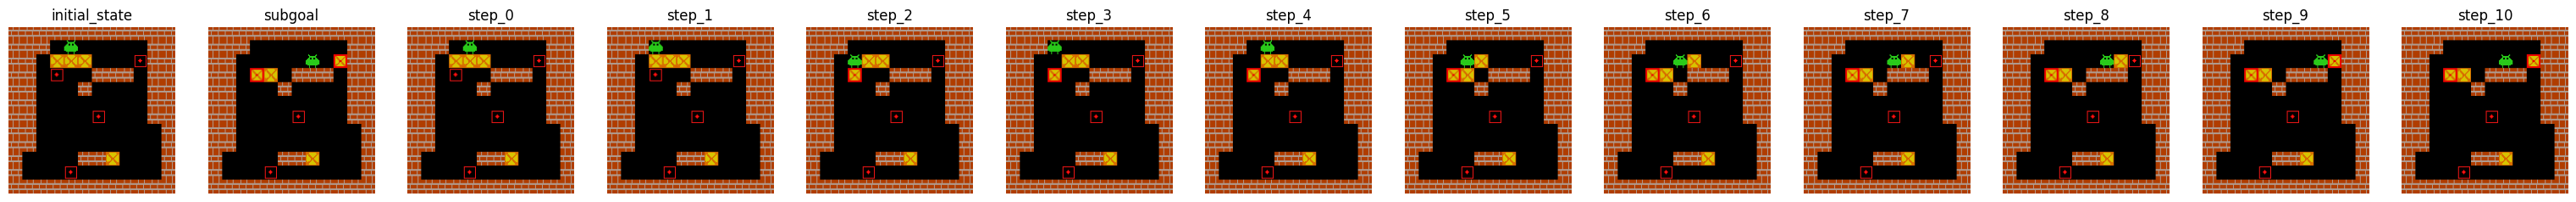

Additional validation using validator


2025-01-26 21:37:36.359 | INFO     | __main__:<module>:16 - Validator result: True (path: [2, 1, 0, 3, 1, 3, 3, 3, 3, 2])


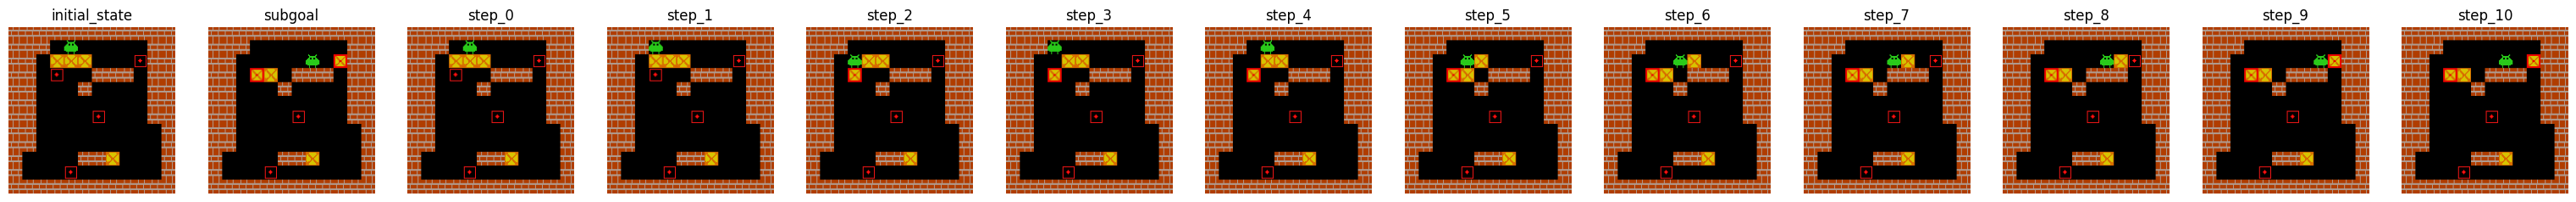

In [19]:
from carl.inference_components.validator import BasicValidator


validator = BasicValidator(env, cllp, 10)

for input_node, result, subgoals in zip(nodes, results, [subgoals_0, subgoals_1]):
    logger.info(f'Verification result for node: {result}')
    for i in range(len(result.paths)):
        trajectory = cllp_utils.trajectory_from_actions(env, input_node.state, result.paths[i])
        subgoal_state = subgoals[i].state
        display(env.many_states_to_repr([input_node.state, subgoal_state, *trajectory],
                                        ['initial_state', 'subgoal', *[f'step_{i}' for i in range(len(trajectory))]]))    

## With small, randomly generated goals

In [24]:
initial_state = next(dataloader).cpu().numpy()[0]

In [25]:
def get_goals(
    gen_env: SokobanEnv, gen_initial_state: np.ndarray, num_goals: int = 5, steps_to_goal: int = 7
) -> list[np.ndarray]:
    out_goals = []
    for _ in range(num_goals):
        gen_state = gen_initial_state.copy()
        for _ in range(steps_to_goal):
            action = np.random.randint(0, 4)
            gen_env.set_state(gen_state)
            gen_state, _, done, _ = gen_env.step(action)
            if done:
                break
        out_goals.append(gen_state.copy())
    return out_goals


random_small_goals = get_goals(
    gen_env=env, gen_initial_state=initial_state, num_goals=10, steps_to_goal=3
)

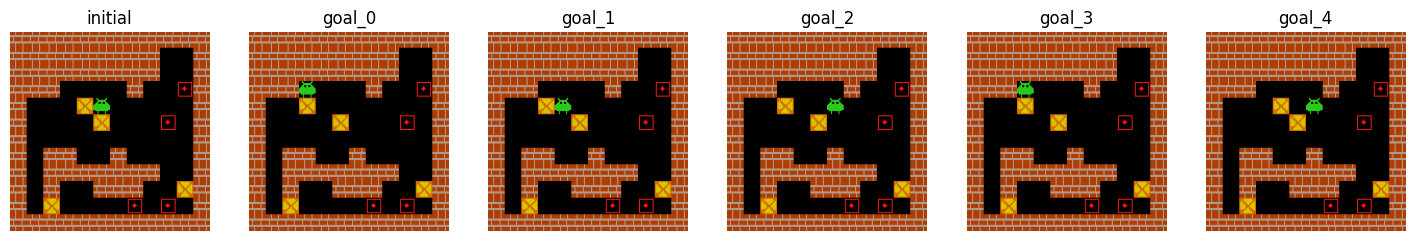

In [26]:
env.many_states_to_repr(
    [initial_state] + random_small_goals[:5],
    titles=['initial'] + [f'goal_{i}' for i in range(len(random_small_goals[:5]))],
)

In [27]:
cllp_utils.verify_cllp_reaches_subgoals_from_initial_state(
    cllp=cllp,
    goals=random_small_goals,
    initial_state=initial_state,
    env_creation_fn=lambda: env,
    max_radius=7,
    add_first_batch_to_node_computations=True,
)

CLLPVerificationResult(success_rate=1.0, total_goals=10, reached=array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True]), calls=10, cllp_samples_in_calls=22, node_computations=22, paths=[[2, 0, 2], [2], [2, 3, 3], [2, 0, 2], [3], [1, 0, 3], [2, 2, 0, 3, 1], [2], [1], [1]])